In [1]:
import mne
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, cohen_kappa_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from mne.decoding import CSP

In [2]:
# Load raw EEG signal from GDF file
raw = mne.io.read_raw_gdf(
    '/home/ali/Desktop/Dataset/Downloaded/BCICIV_2a/BCICIV_2a/A01T.gdf',
    preload=True, verbose=False
)
print(raw.info)

# Extract events and their string-to-integer ID mapping from annotations
events, event_id = mne.events_from_annotations(raw, verbose=False)
print()
print(f'event ID is: {event_id}')
print()
print(f' First 10 events are: {events[:10]}')
print()
print('Left Hand = 768'+'    '+'Righthand = 770'+ '    ' + 'Fppt = 771' + '    ' + 'Tongue = 772')

# Load true class labels from companion MAT file (GDF labels are unreliable)
mat = scipy.io.loadmat(
    '/home/ali/Desktop/Dataset/Downloaded/BCICIV_2a/true_labels/A01T.mat'
)
y = mat['classlabel'].flatten()  # shape: (n_trials,), values: 1–4
print()
print(f'Label shape is: {y.shape}')
print(f'Label tags are: {np.unique(y)}')

/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG-Fz, EEG-0, EEG-1, EEG-2, EEG-3, EEG-4, EEG-5, EEG-C3, EEG-6, ...
 chs: 25 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2005-01-17 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: A01, sex: 0, last_name: X, birthday: 1983-01-17>
>

event ID is: {np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}

 First 10 events are: [[    0     0     5]
 [    0     0     3]
 [29683     0     5]
 [29683     0     4]
 [49955     0     5]
 [49955     0     2]
 [91518     0     5]
 [91868     0     6]
 [92368     0    10]
 [93871     0     6]]

Left Hand = 768    Righthand = 770    Fppt = 771    Tongue = 772

Label shape is: (288,)
Label tags are: [1 2 3 4]


In [3]:
# Keep only EEG channels; discard EOG and other sensor types
raw.pick('eeg')

# Band-pass filter: retain 8–32 Hz (mu + beta rhythms relevant to Motor Imagery)
raw.filter(8., 32., fir_design='firwin', verbose=False)

# --- Epoch extraction ---
# Select only the four MI cue event IDs (769–772); discard rest/artifact markers

cue_ids = {}
for k, v in event_id.items():
    if any(c in k for c in ['769', '770', '771', '772']):
        cue_ids[k] = v  
print('cue ID is:')
print(cue_ids)
print()

# Epoch the continuous signal around each cue onset
# tmin=0.5s: skip the visual evoked potential; tmax=2.5s: 2s of pure imagery
epochs = mne.Epochs(
    raw, events, event_id=cue_ids,
    tmin=0.5, tmax=2.5,
    baseline=None, preload=True, verbose=False
)

# Convert to NumPy array: shape (n_trials, n_channels, n_samples)
X = epochs.get_data()

# Align X and y in case of a minor trial-count mismatch
n = min(len(X), len(y))
X, y = X[:n], y[:n]

print(f'X: {X.shape}, y: {y.shape}')

cue ID is:
{np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}

X: (288, 25, 501), y: (288,)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# ITR (Information Transfer Rate) Computation
# Quantifies BCI throughput in bits/min using Wolpaw's formula.
# Returns 0 when accuracy is at or below chance level (p ≤ 1/N),
# since the channel carries no usable information in that regime.
# ─────────────────────────────────────────────────────────────────────────────
def compute_itr(n_classes, accuracy, trial_duration_sec):
    p, N = accuracy, n_classes
    if p <= 1 / N:
        return 0.0
    B = p * np.log2(p) + (1 - p) * np.log2((1 - p) / (N - 1)) + np.log2(N)
    return B * (60 / trial_duration_sec)

Computing rank from data with rank=None
    Using tolerance 4.2e-05 (2.2e-16 eps * 25 dim * 7.6e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Estimating class=4 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 4.2e-05 (2.2e-16 eps * 25 dim * 7.6e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Estimating class=4 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 4.2e-0

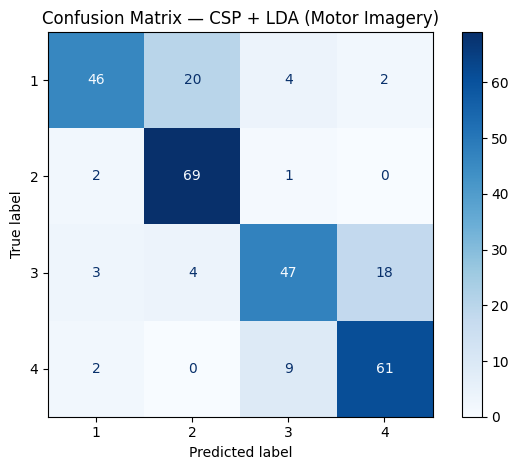

In [5]:
# --- Pipeline: CSP + LDA ---
pipeline = Pipeline([
    ('csp', CSP(n_components=4, reg='ledoit_wolf', log=True)),
    ('lda', LDA(solver='lsqr', shrinkage='auto'))
])

# --- Cross-Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(pipeline, X, y, cv=cv)

# --- Metrics ---
acc   = accuracy_score(y, y_pred)
kappa = cohen_kappa_score(y, y_pred)
prec  = precision_score(y, y_pred, average='macro')
reca  = recall_score(y, y_pred, average='macro')
f1    = f1_score(y, y_pred, average='macro')
itr   = compute_itr(n_classes=4, accuracy=acc, trial_duration_sec=4.0)

print(f"Accuracy  : {acc:.4f}")
print(f"Kappa     : {kappa:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {reca:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ITR       : {itr:.2f} bits/min")

# --- Confusion Matrix ---
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — CSP + LDA (Motor Imagery)")
plt.tight_layout()
plt.show()